In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, roc_curve, 
                            multilabel_confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_original = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks.csv')
df_corrected = pd.read_csv('ml-dataset-50-50-idle-timeout-2-17-10-2025-multiple-attacks-corrected.csv')

print(f"\nOriginal Dataset shape: {df_original.shape}")
print(f"Corrected Dataset shape: {df_corrected.shape}")


Original Dataset shape: (3354, 72)
Corrected Dataset shape: (3354, 72)


In [3]:
print("DATASET STATISTICS COMPARISON")

print("\nORIGINAL DATASET:")
print(f"  Total samples: {len(df_original)}")
print(f"  Normal samples: {(df_original['attack'] == 0).sum()} ({(df_original['attack'] == 0).sum() / len(df_original) * 100:.2f}%)")
print(f"  Attack samples: {df_original['attack'].sum()} ({df_original['attack'].sum() / len(df_original) * 100:.2f}%)")
print(f"    - SYN attacks: {df_original['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_original['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_original['attack_icmp'].sum()}")

print("\nCORRECTED DATASET:")
print(f"  Total samples: {len(df_corrected)}")
print(f"  Normal samples: {(df_corrected['attack'] == 0).sum()} ({(df_corrected['attack'] == 0).sum() / len(df_corrected) * 100:.2f}%)")
print(f"  Attack samples: {df_corrected['attack'].sum()} ({df_corrected['attack'].sum() / len(df_corrected) * 100:.2f}%)")
print(f"    - SYN attacks: {df_corrected['attack_syn'].sum()}")
print(f"    - UDP attacks: {df_corrected['attack_udp'].sum()}")
print(f"    - ICMP attacks: {df_corrected['attack_icmp'].sum()}")

print("\nIMPROVEMENT:")
print(f"  Additional attack samples: {df_corrected['attack'].sum() - df_original['attack'].sum()}")
print(f"    - Additional SYN: {df_corrected['attack_syn'].sum() - df_original['attack_syn'].sum()}")
print(f"    - Additional UDP: {df_corrected['attack_udp'].sum() - df_original['attack_udp'].sum()}")
print(f"    - Additional ICMP: {df_corrected['attack_icmp'].sum() - df_original['attack_icmp'].sum()}")

DATASET STATISTICS COMPARISON

ORIGINAL DATASET:
  Total samples: 3354
  Normal samples: 1777 (52.98%)
  Attack samples: 1577 (47.02%)
    - SYN attacks: 634
    - UDP attacks: 599
    - ICMP attacks: 344

CORRECTED DATASET:
  Total samples: 3354
  Normal samples: 1583 (47.20%)
  Attack samples: 1771 (52.80%)
    - SYN attacks: 734
    - UDP attacks: 651
    - ICMP attacks: 386

IMPROVEMENT:
  Additional attack samples: 194
    - Additional SYN: 100
    - Additional UDP: 52
    - Additional ICMP: 42


In [4]:
def prepare_data(df, task='binary'):
    """
    Prepare data for training.
    
    Args:
        df: DataFrame with features and labels
        task: 'binary' for attack vs normal, 'multiclass' for attack type classification
    
    Returns:
        X, y split into train and test sets
    """
    # Features (excluding timestamp and all attack labels)
    feature_cols = [col for col in df.columns if col not in ['timestamp', 'attack', 'attack_syn', 'attack_udp', 'attack_icmp']]
    X = df[feature_cols]
    
    if task == 'binary':
        # Binary classification: attack vs normal
        y = df['attack']
    elif task == 'multiclass':
        # Multi-class classification: normal (0), syn (1), udp (2), icmp (3)
        y = np.zeros(len(df), dtype=int)
        y[df['attack_syn'] == 1] = 1
        y[df['attack_udp'] == 1] = 2
        y[df['attack_icmp'] == 1] = 3
    
    return X, y

In [5]:
def train_and_evaluate_binary(X_train, X_test, y_train, y_test, dataset_name):
    """
    Train and evaluate binary classifier (attack vs normal).
    """
    print(f"\n{'='*80}")
    print(f"BINARY CLASSIFICATION - {dataset_name}")
    print(f"{'='*80}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    print("\nTraining Random Forest model...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=0
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test_scaled)
    y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"\n{'RESULTS':^40}")
    print("-" * 40)
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1-Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'CONFUSION MATRIX':^40}")
    print("-" * 40)
    print(f"True Negatives:  {cm[0,0]:>6}")
    print(f"False Positives: {cm[0,1]:>6}")
    print(f"False Negatives: {cm[1,0]:>6}")
    print(f"True Positives:  {cm[1,1]:>6}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'model': rf_model,
        'scaler': scaler,
        'metrics': metrics,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'feature_importance': feature_importance
    }

In [6]:
#%%
def train_and_evaluate_multiclass(X_train, X_test, y_train, y_test, dataset_name):
    """
    Train and evaluate multi-class classifier (normal, syn, udp, icmp).
    """
    print(f"\n{'='*80}")
    print(f"MULTI-CLASS CLASSIFICATION - {dataset_name}")
    print(f"{'='*80}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    print("\nTraining Random Forest model...")
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=0
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Per-class metrics
    class_names = ['Normal', 'SYN', 'UDP', 'ICMP']
    
    print(f"\n{'RESULTS':^60}")
    print("-" * 60)
    print(f"Overall Accuracy: {accuracy:.4f}")
    
    print(f"\n{'Classification Report':^60}")
    print("-" * 60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return {
        'model': rf_model,
        'scaler': scaler,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred,
        'feature_importance': feature_importance,
        'class_names': class_names
    }

In [7]:
# Prepare data for both datasets
# Binary classification data
X_orig_bin, y_orig_bin = prepare_data(df_original, task='binary')
X_corr_bin, y_corr_bin = prepare_data(df_corrected, task='binary')

# Multi-class classification data
X_orig_multi, y_orig_multi = prepare_data(df_original, task='multiclass')
X_corr_multi, y_corr_multi = prepare_data(df_corrected, task='multiclass')

# Split data
X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin = train_test_split(
    X_orig_bin, y_orig_bin, test_size=0.2, random_state=42, stratify=y_orig_bin
)

X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin = train_test_split(
    X_corr_bin, y_corr_bin, test_size=0.2, random_state=42, stratify=y_corr_bin
)

X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi = train_test_split(
    X_orig_multi, y_orig_multi, test_size=0.2, random_state=42, stratify=y_orig_multi
)

X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi = train_test_split(
    X_corr_multi, y_corr_multi, test_size=0.2, random_state=42, stratify=y_corr_multi
)

print("Data preparation complete!")
print(f"Number of features: {X_orig_bin.shape[1]}")

Data preparation complete!
Number of features: 67


In [8]:
# Train and evaluate binary classification
print("BINARY CLASSIFICATION (ATTACK vs NORMAL)")

results_orig_bin = train_and_evaluate_binary(
    X_train_orig_bin, X_test_orig_bin, y_train_orig_bin, y_test_orig_bin,
    "ORIGINAL DATASET"
)

results_corr_bin = train_and_evaluate_binary(
    X_train_corr_bin, X_test_corr_bin, y_train_corr_bin, y_test_corr_bin,
    "CORRECTED DATASET"
)

BINARY CLASSIFICATION (ATTACK vs NORMAL)

BINARY CLASSIFICATION - ORIGINAL DATASET

Training Random Forest model...

                RESULTS                 
----------------------------------------
Accuracy:  0.9195
Precision: 0.8635
Recall:    0.9841
F1-Score:  0.9199
ROC-AUC:   0.9685

            CONFUSION MATRIX            
----------------------------------------
True Negatives:     307
False Positives:     49
False Negatives:      5
True Positives:     310

BINARY CLASSIFICATION - CORRECTED DATASET

Training Random Forest model...

                RESULTS                 
----------------------------------------
Accuracy:  0.9598
Precision: 0.9383
Recall:    0.9887
F1-Score:  0.9629
ROC-AUC:   0.9936

            CONFUSION MATRIX            
----------------------------------------
True Negatives:     294
False Positives:     23
False Negatives:      4
True Positives:     350


In [9]:
# Train and evaluate multi-class classification
print("MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)")

results_orig_multi = train_and_evaluate_multiclass(
    X_train_orig_multi, X_test_orig_multi, y_train_orig_multi, y_test_orig_multi,
    "ORIGINAL DATASET"
)

results_corr_multi = train_and_evaluate_multiclass(
    X_train_corr_multi, X_test_corr_multi, y_train_corr_multi, y_test_corr_multi,
    "CORRECTED DATASET"
)

MULTI-CLASS CLASSIFICATION (NORMAL, SYN, UDP, ICMP)

MULTI-CLASS CLASSIFICATION - ORIGINAL DATASET

Training Random Forest model...

                          RESULTS                           
------------------------------------------------------------
Overall Accuracy: 0.9001

                   Classification Report                    
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.96      0.88      0.92       355
         SYN       0.78      0.90      0.83       127
         UDP       0.89      0.99      0.94       120
        ICMP       0.88      0.87      0.88        69

    accuracy                           0.90       671
   macro avg       0.88      0.91      0.89       671
weighted avg       0.91      0.90      0.90       671


MULTI-CLASS CLASSIFICATION - CORRECTED DATASET

Training Random Forest model...

                          RESULTS                           
-------------------

In [10]:
print("COMPARISON SUMMARY")

print("BINARY CLASSIFICATION IMPROVEMENT")

metrics_comparison_bin = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Original': [
        results_orig_bin['metrics']['accuracy'],
        results_orig_bin['metrics']['precision'],
        results_orig_bin['metrics']['recall'],
        results_orig_bin['metrics']['f1'],
        results_orig_bin['metrics']['roc_auc']
    ],
    'Corrected': [
        results_corr_bin['metrics']['accuracy'],
        results_corr_bin['metrics']['precision'],
        results_corr_bin['metrics']['recall'],
        results_corr_bin['metrics']['f1'],
        results_corr_bin['metrics']['roc_auc']
    ]
})

metrics_comparison_bin['Improvement'] = metrics_comparison_bin['Corrected'] - metrics_comparison_bin['Original']
metrics_comparison_bin['Improvement %'] = (metrics_comparison_bin['Improvement'] / metrics_comparison_bin['Original']) * 100

print(metrics_comparison_bin.to_string(index=False))

print("MULTI-CLASS CLASSIFICATION IMPROVEMENT")

accuracy_improvement = results_corr_multi['accuracy'] - results_orig_multi['accuracy']
accuracy_improvement_pct = (accuracy_improvement / results_orig_multi['accuracy']) * 100

print(f"Original Accuracy:  {results_orig_multi['accuracy']:.4f}")
print(f"Corrected Accuracy: {results_corr_multi['accuracy']:.4f}")
print(f"Improvement:        {accuracy_improvement:+.4f} ({accuracy_improvement_pct:+.2f}%)")

COMPARISON SUMMARY
BINARY CLASSIFICATION IMPROVEMENT
   Metric  Original  Corrected  Improvement  Improvement %
 Accuracy  0.919523   0.959762     0.040238       4.376013
Precision  0.863510   0.938338     0.074828       8.665571
   Recall  0.984127   0.988701     0.004574       0.464735
 F1-Score  0.919881   0.962861     0.042980       4.672317
  ROC-AUC  0.968544   0.993557     0.025013       2.582578
MULTI-CLASS CLASSIFICATION IMPROVEMENT
Original Accuracy:  0.9001
Corrected Accuracy: 0.9493
Improvement:        +0.0492 (+5.46%)


In [11]:
# Visualizations
color_original = '#3498db'  # Blue
color_corrected = '#2ecc71'  # Green
color_improvement_pos = '#27ae60'  # Dark green
color_improvement_neg = '#e74c3c'  # Red

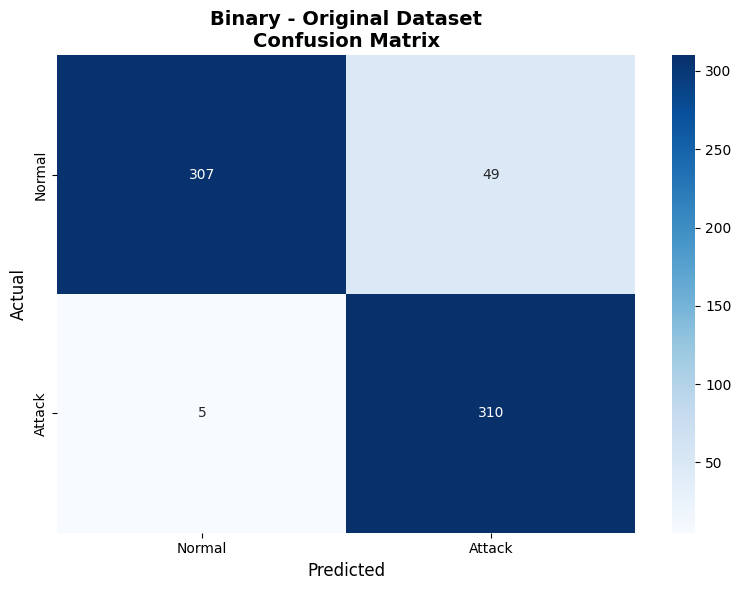

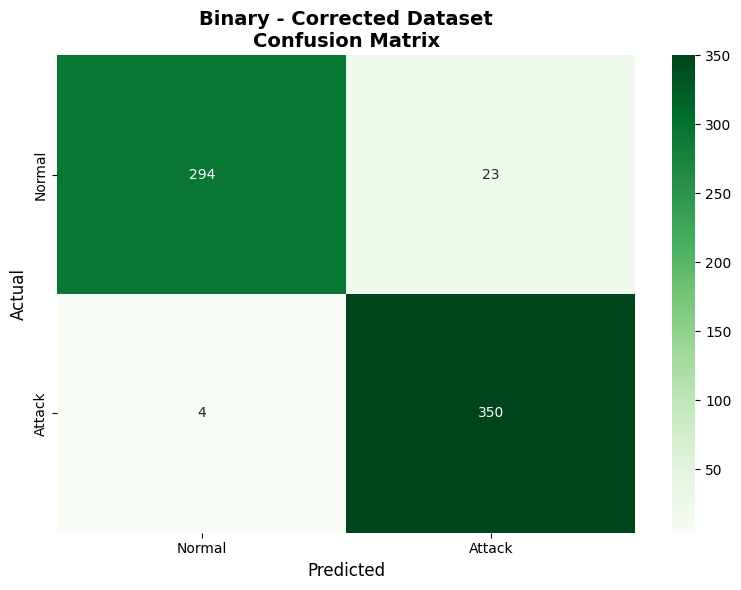

In [12]:
# 1. Binary Classification - Confusion Matrices Comparison
plt.figure(figsize=(8, 6))
sns.heatmap(results_orig_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary - Original Dataset\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# 1.1 Binary Classification - Corrected Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(results_corr_bin['confusion_matrix'], 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            cbar=True,
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Binary - Corrected Dataset\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('random_forest_results/binary_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

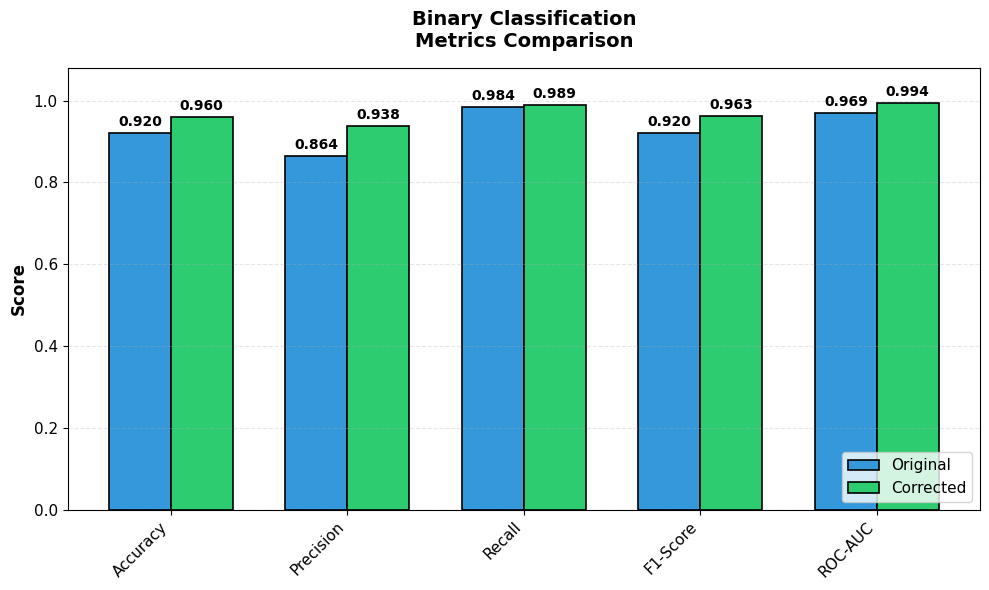

In [13]:
# 2. Binary Classification - Metrics Comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_comparison_bin))
width = 0.35

bars1 = plt.bar(x - width/2, metrics_comparison_bin['Original'], width, 
                label='Original', color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x + width/2, metrics_comparison_bin['Corrected'], width, 
                label='Corrected', color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nMetrics Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, metrics_comparison_bin['Metric'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.08)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

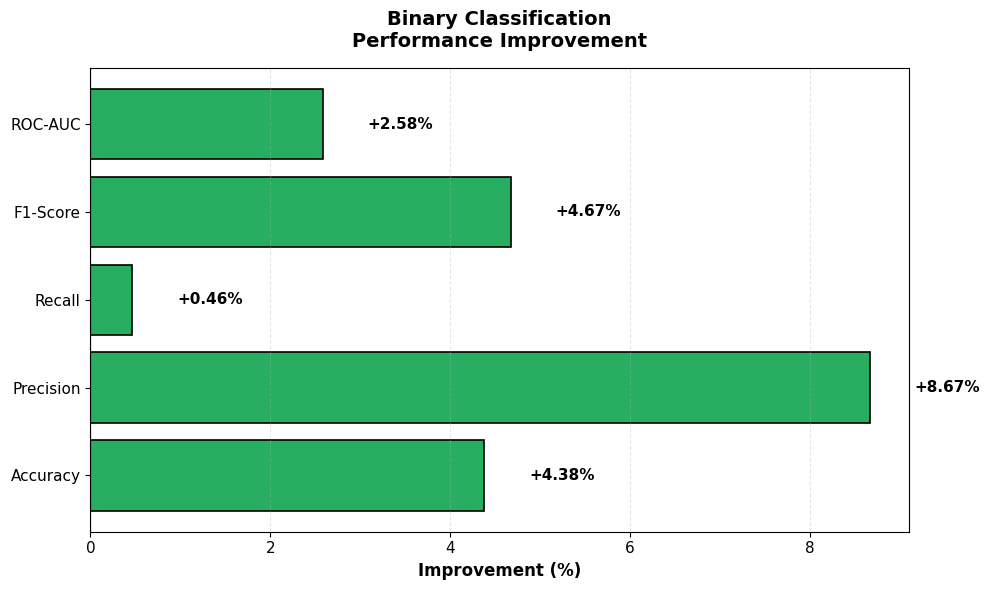

In [14]:
# 3. Binary Classification - Improvement
plt.figure(figsize=(10, 6))
colors = [color_improvement_pos if x > 0 else color_improvement_neg 
          for x in metrics_comparison_bin['Improvement %']]
bars = plt.barh(metrics_comparison_bin['Metric'], metrics_comparison_bin['Improvement %'], 
                color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, metrics_comparison_bin['Improvement %'])):
    width = bar.get_width()
    label_x = width + (0.5 if width > 0 else -0.5)
    plt.text(label_x, bar.get_y() + bar.get_height()/2., f'{val:+.2f}%',
            ha='left' if width > 0 else 'right', va='center', 
            fontsize=11, fontweight='bold')

plt.xlabel('Improvement (%)', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nPerformance Improvement', fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_performance_improvement.png', dpi=300, bbox_inches='tight')
plt.show()

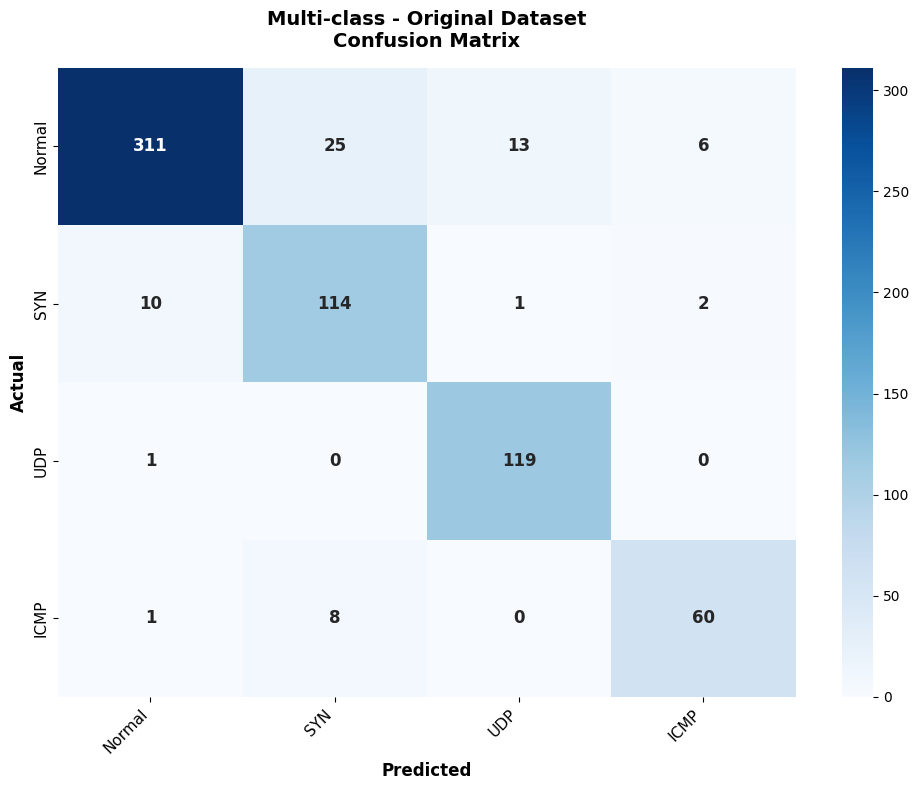

In [15]:
# 4. Multi-class - Original Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_orig_multi['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=results_orig_multi['class_names'],
            yticklabels=results_orig_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class - Original Dataset\nConfusion Matrix', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_original_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

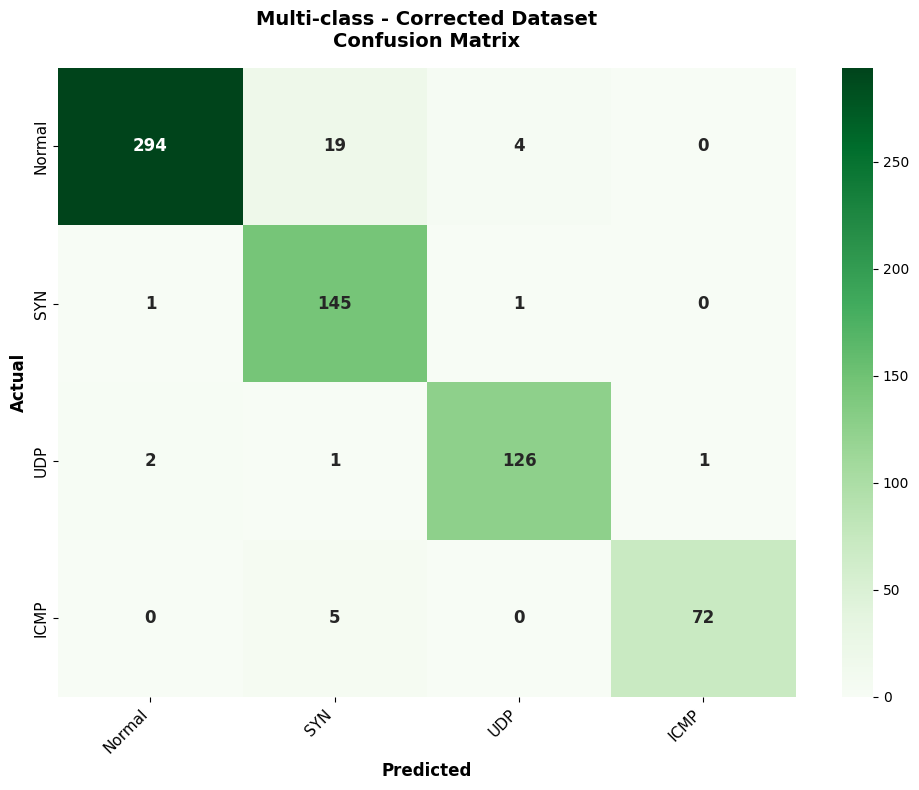

In [16]:
# 5. Multi-class - Corrected Dataset Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(results_corr_multi['confusion_matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=results_corr_multi['class_names'],
            yticklabels=results_corr_multi['class_names'],
            cbar=True, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Multi-class - Corrected Dataset\nConfusion Matrix', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_corrected_dataset_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

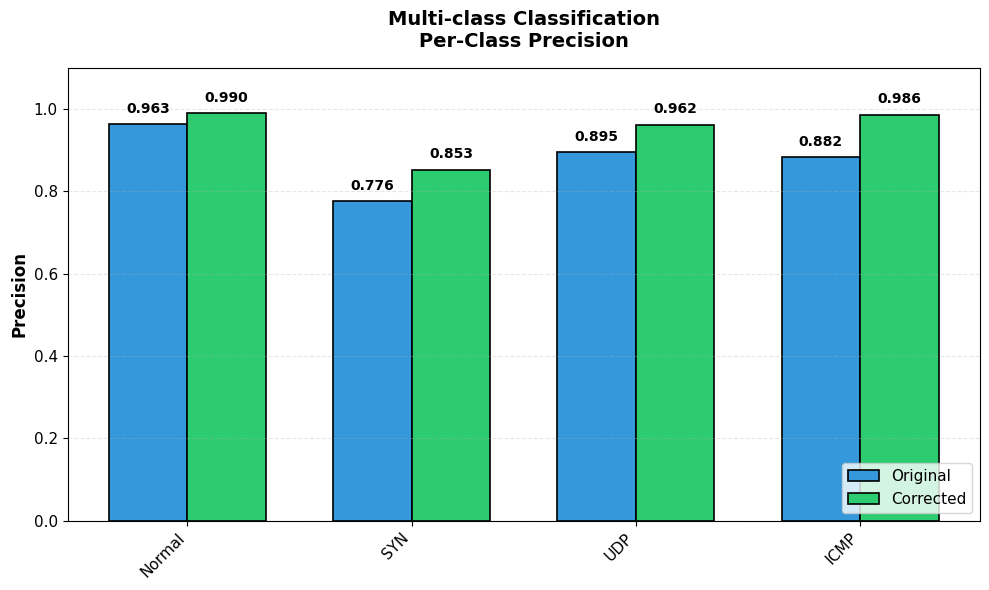

In [17]:
# 6. Per-class Precision Comparison (Multi-class)
plt.figure(figsize=(10, 6))
from sklearn.metrics import precision_score, recall_score

prec_orig = precision_score(y_test_orig_multi, results_orig_multi['y_pred'], average=None, zero_division=0)
prec_corr = precision_score(y_test_corr_multi, results_corr_multi['y_pred'], average=None, zero_division=0)

x_pos = np.arange(len(results_orig_multi['class_names']))
width = 0.35

bars1 = plt.bar(x_pos - width/2, prec_orig, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, prec_corr, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Multi-class Classification\nPer-Class Precision', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, results_orig_multi['class_names'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_classification_per_class_precision.png', dpi=300, bbox_inches='tight')
plt.show()

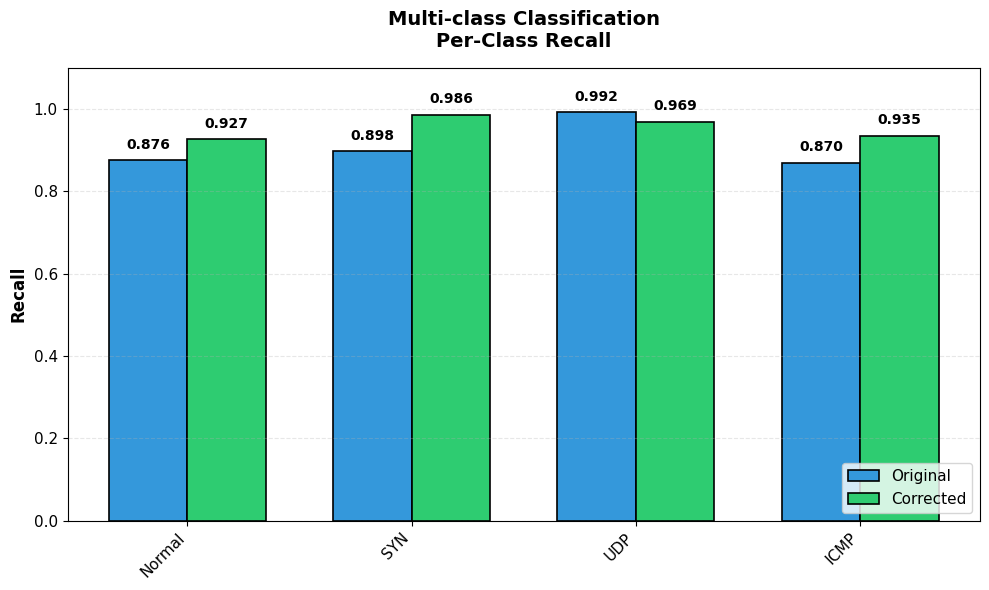

In [18]:
# 7. Per-class Recall Comparison (Multi-class)
plt.figure(figsize=(10, 6))
recall_orig = recall_score(y_test_orig_multi, results_orig_multi['y_pred'], average=None, zero_division=0)
recall_corr = recall_score(y_test_corr_multi, results_corr_multi['y_pred'], average=None, zero_division=0)

bars1 = plt.bar(x_pos - width/2, recall_orig, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, recall_corr, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Recall', fontsize=12, fontweight='bold')
plt.title('Multi-class Classification\nPer-Class Recall', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, results_orig_multi['class_names'], rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='lower right')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/multi_class_classification_per_class_recall.png', dpi=300, bbox_inches='tight')
plt.show()

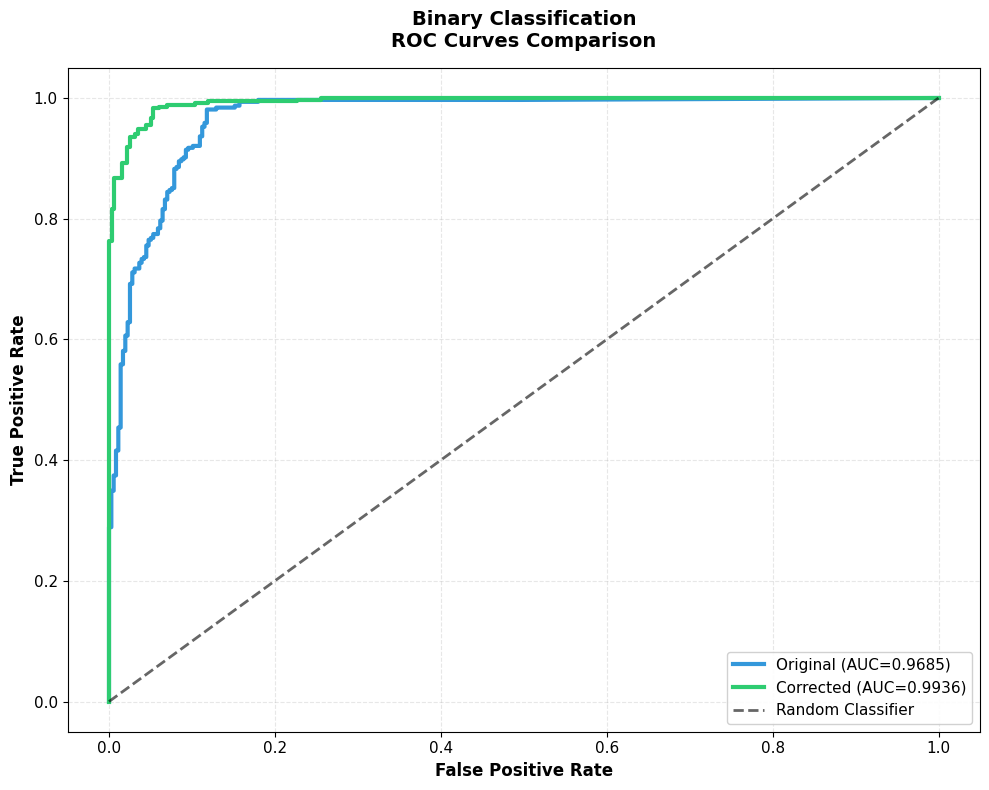

In [19]:
# 8. ROC Curves Comparison (Binary)
plt.figure(figsize=(10, 8))
from sklearn.metrics import roc_curve

fpr_orig, tpr_orig, _ = roc_curve(results_orig_bin['y_test'], results_orig_bin['y_pred_proba'])
fpr_corr, tpr_corr, _ = roc_curve(results_corr_bin['y_test'], results_corr_bin['y_pred_proba'])

plt.plot(fpr_orig, tpr_orig, linewidth=3, 
         label=f'Original (AUC={results_orig_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_original, linestyle='-')
plt.plot(fpr_corr, tpr_corr, linewidth=3, 
         label=f'Corrected (AUC={results_corr_bin["metrics"]["roc_auc"]:.4f})', 
         color=color_corrected, linestyle='-')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.6)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Binary Classification\nROC Curves Comparison', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/binary_classification_roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

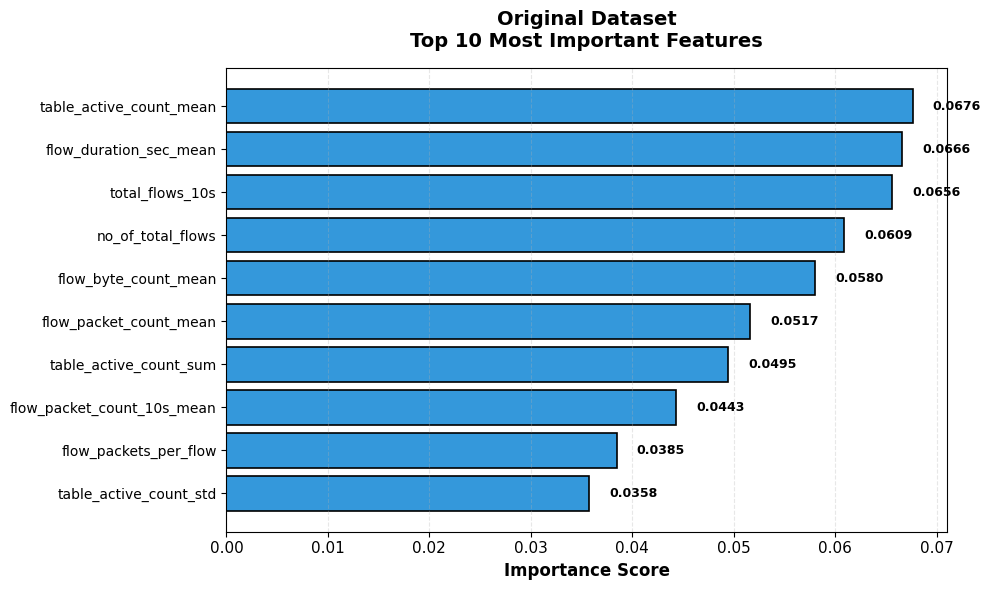

In [20]:
# 9. Feature Importance Top 10 - Original
plt.figure(figsize=(10, 6))
top_features_orig = results_orig_bin['feature_importance'].head(10)
bars = plt.barh(range(len(top_features_orig)), top_features_orig['importance'], 
                color=color_original, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features_orig['importance'])):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2., 
            f'{val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

plt.yticks(range(len(top_features_orig)), top_features_orig['feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Original Dataset\nTop 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('random_forest_results/original_dataset_top10_most_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

Top 10 features shape: (10, 2)


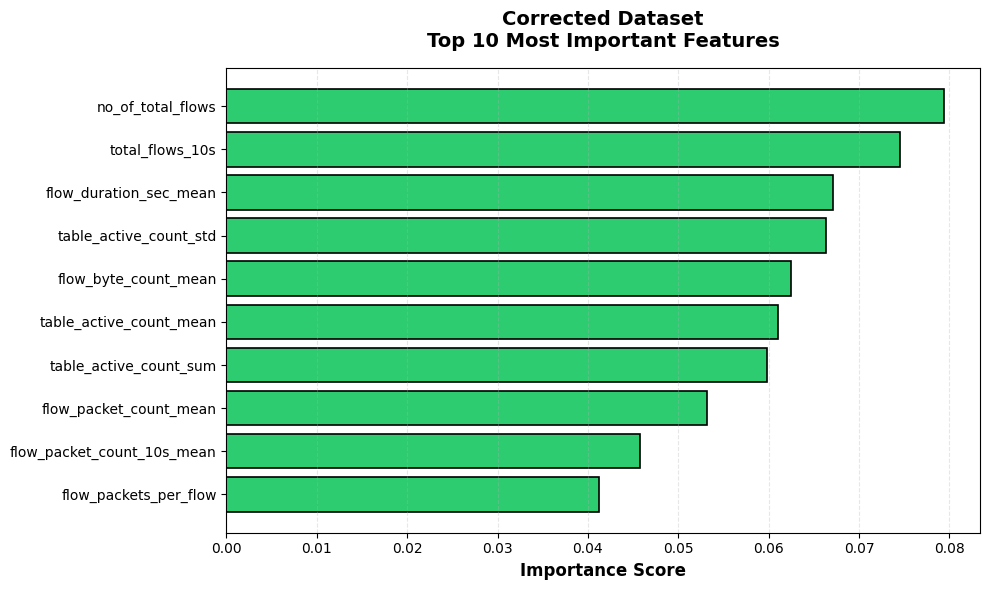

In [21]:
# 10. Feature Importance Top 10 - Corrected
plt.figure(figsize=(10, 6))
top_features_corr = results_corr_bin['feature_importance'].head(10).copy()
print(f"Top 10 features shape: {top_features_corr.shape}")

# Simple plot without text labels first
plt.barh(range(len(top_features_corr)), top_features_corr['importance'], 
         color=color_corrected, edgecolor='black', linewidth=1.2)

plt.yticks(range(len(top_features_corr)), top_features_corr['feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Corrected Dataset\nTop 10 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/corrected_dataset_top10_important_features.png', dpi=300, bbox_inches='tight')
plt.show()

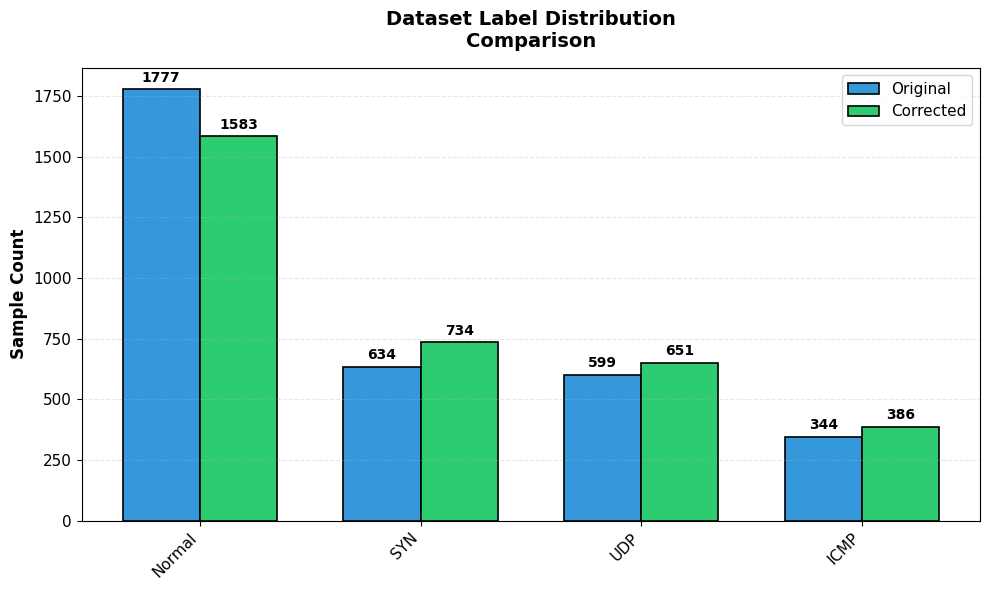

In [22]:
# 11. Dataset Label Distribution
plt.figure(figsize=(10, 6))
labels = ['Normal', 'SYN', 'UDP', 'ICMP']
orig_counts = [
    (df_original['attack'] == 0).sum(),
    df_original['attack_syn'].sum(),
    df_original['attack_udp'].sum(),
    df_original['attack_icmp'].sum()
]
corr_counts = [
    (df_corrected['attack'] == 0).sum(),
    df_corrected['attack_syn'].sum(),
    df_corrected['attack_udp'].sum(),
    df_corrected['attack_icmp'].sum()
]

x_pos = np.arange(len(labels))
width = 0.35

bars1 = plt.bar(x_pos - width/2, orig_counts, width, label='Original', 
                color=color_original, edgecolor='black', linewidth=1.2)
bars2 = plt.bar(x_pos + width/2, corr_counts, width, label='Corrected', 
                color=color_corrected, edgecolor='black', linewidth=1.2)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel('Sample Count', fontsize=12, fontweight='bold')
plt.title('Dataset Label Distribution\nComparison', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x_pos, labels, rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('random_forest_results/dataset_label_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

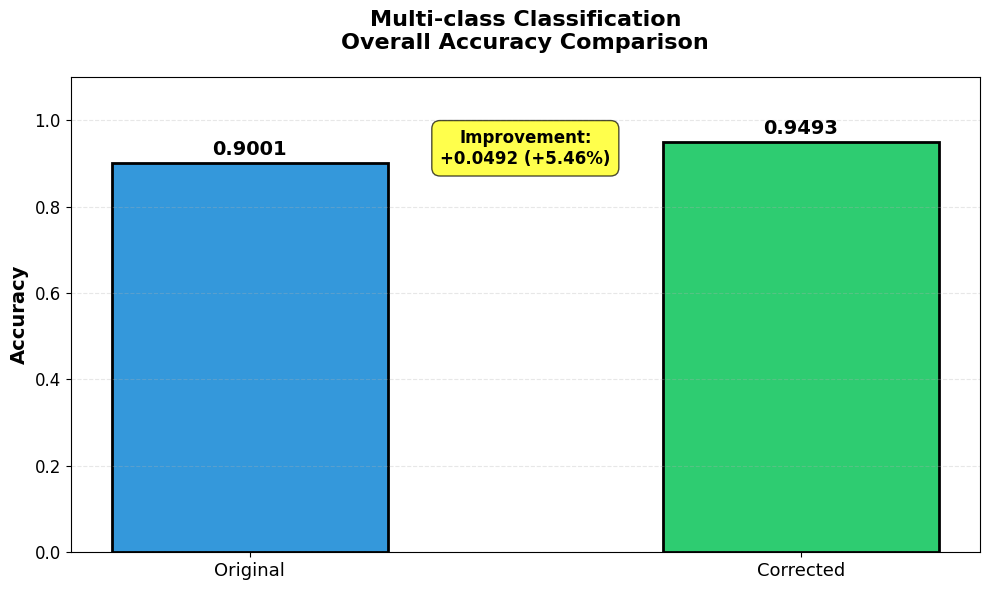

In [23]:
# Multi-class Accuracy Comparison
fig2, ax = plt.subplots(1, 1, figsize=(10, 6))

accuracy_comparison = pd.DataFrame({
    'Dataset': ['Original', 'Corrected'],
    'Accuracy': [results_orig_multi['accuracy'], results_corr_multi['accuracy']]
})

bars = plt.bar(accuracy_comparison['Dataset'], accuracy_comparison['Accuracy'],
               color=[color_original, color_corrected], 
               edgecolor='black', linewidth=2, width=0.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.4f}', ha='center', va='bottom', 
            fontsize=14, fontweight='bold')

# Add improvement annotation
improvement = results_corr_multi['accuracy'] - results_orig_multi['accuracy']
improvement_pct = (improvement / results_orig_multi['accuracy']) * 100

plt.annotate(f'Improvement:\n+{improvement:.4f} ({improvement_pct:+.2f}%)',
            xy=(0.5, max(accuracy_comparison['Accuracy']) - 0.05),
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
plt.title('Multi-class Classification\nOverall Accuracy Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# Binary classification metrics
metrics_comparison_bin.to_csv('random_forest_results/binary_classification_comparison.csv', index=False)

# Multi-class per-class metrics
multiclass_metrics = pd.DataFrame({
    'Class': results_orig_multi['class_names'],
    'Precision_Original': prec_orig,
    'Precision_Corrected': prec_corr,
    'Recall_Original': recall_orig,
    'Recall_Corrected': recall_corr
})
multiclass_metrics['Precision_Improvement'] = multiclass_metrics['Precision_Corrected'] - multiclass_metrics['Precision_Original']
multiclass_metrics['Recall_Improvement'] = multiclass_metrics['Recall_Corrected'] - multiclass_metrics['Recall_Original']

multiclass_metrics.to_csv('random_forest_results/multiclass_classification_comparison.csv', index=False)

results_orig_bin['feature_importance'].to_csv('random_forest_results/feature_importance_random_forest_original.csv', index=False)
results_corr_bin['feature_importance'].to_csv('random_forest_results/feature_importance_random_fores_corrected.csv', index=False)

In [25]:
from scipy import stats
from sklearn.utils import resample

def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, confidence=0.95):
    """
    Calculate bootstrap confidence interval for a metric.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        metric_func: Metric function to evaluate
        n_iterations: Number of bootstrap iterations
        confidence: Confidence level (default 0.95)
    
    Returns:
        (mean, lower_bound, upper_bound)
    """
    scores = []
    n_size = len(y_true)
    
    for i in range(n_iterations):
        # Bootstrap sample
        indices = resample(range(n_size), n_samples=n_size, replace=True)
        y_true_boot = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
        y_pred_boot = y_pred[indices]
        
        # Calculate metric
        score = metric_func(y_true_boot, y_pred_boot)
        scores.append(score)
    
    # Calculate confidence interval
    alpha = 1 - confidence
    lower = np.percentile(scores, (alpha/2) * 100)
    upper = np.percentile(scores, (1 - alpha/2) * 100)
    mean = np.mean(scores)
    
    return mean, lower, upper

In [26]:
# Binary Classification - 95% CI for Original Dataset
print("="*80)
print("BINARY CLASSIFICATION - ORIGINAL DATASET")
print("95% Confidence Intervals (Bootstrap, n=1000)")
print("="*80)

metrics_with_ci_orig = {}

# Accuracy
acc_mean, acc_lower, acc_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    accuracy_score
)
metrics_with_ci_orig['Accuracy'] = (acc_mean, acc_lower, acc_upper)
print(f"\nAccuracy:  {acc_mean:.4f} (95% CI: [{acc_lower:.4f}, {acc_upper:.4f}])")

# Precision
prec_mean, prec_lower, prec_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['Precision'] = (prec_mean, prec_lower, prec_upper)
print(f"Precision: {prec_mean:.4f} (95% CI: [{prec_lower:.4f}, {prec_upper:.4f}])")

# Recall
rec_mean, rec_lower, rec_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['Recall'] = (rec_mean, rec_lower, rec_upper)
print(f"Recall:    {rec_mean:.4f} (95% CI: [{rec_lower:.4f}, {rec_upper:.4f}])")

# F1-Score
f1_mean, f1_lower, f1_upper = bootstrap_metric(
    results_orig_bin['y_test'], 
    results_orig_bin['y_pred'],
    lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_orig['F1-Score'] = (f1_mean, f1_lower, f1_upper)
print(f"F1-Score:  {f1_mean:.4f} (95% CI: [{f1_lower:.4f}, {f1_upper:.4f}])")

BINARY CLASSIFICATION - ORIGINAL DATASET
95% Confidence Intervals (Bootstrap, n=1000)

Accuracy:  0.9188 (95% CI: [0.8986, 0.9374])
Precision: 0.8637 (95% CI: [0.8293, 0.8992])
Recall:    0.9841 (95% CI: [0.9693, 0.9967])
F1-Score:  0.9196 (95% CI: [0.8972, 0.9408])


In [27]:
print("BINARY CLASSIFICATION - CORRECTED DATASET")
print("95% Confidence Intervals (Bootstrap, n=1000)")

metrics_with_ci_corr = {}

# Accuracy
acc_mean, acc_lower, acc_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    accuracy_score
)
metrics_with_ci_corr['Accuracy'] = (acc_mean, acc_lower, acc_upper)
print(f"\nAccuracy:  {acc_mean:.4f} (95% CI: [{acc_lower:.4f}, {acc_upper:.4f}])")

# Precision
prec_mean, prec_lower, prec_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['Precision'] = (prec_mean, prec_lower, prec_upper)
print(f"Precision: {prec_mean:.4f} (95% CI: [{prec_lower:.4f}, {prec_upper:.4f}])")

# Recall
rec_mean, rec_lower, rec_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['Recall'] = (rec_mean, rec_lower, rec_upper)
print(f"Recall:    {rec_mean:.4f} (95% CI: [{rec_lower:.4f}, {rec_upper:.4f}])")

# F1-Score
f1_mean, f1_lower, f1_upper = bootstrap_metric(
    results_corr_bin['y_test'], 
    results_corr_bin['y_pred'],
    lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0)
)
metrics_with_ci_corr['F1-Score'] = (f1_mean, f1_lower, f1_upper)
print(f"F1-Score:  {f1_mean:.4f} (95% CI: [{f1_lower:.4f}, {f1_upper:.4f}])")

BINARY CLASSIFICATION - CORRECTED DATASET
95% Confidence Intervals (Bootstrap, n=1000)

Accuracy:  0.9599 (95% CI: [0.9449, 0.9747])
Precision: 0.9382 (95% CI: [0.9121, 0.9625])
Recall:    0.9884 (95% CI: [0.9766, 0.9973])
F1-Score:  0.9625 (95% CI: [0.9474, 0.9760])


In [28]:
# Statistical Significance Testing
def bootstrap_difference_test(y_test1, y_pred1, y_test2, y_pred2, metric_func, n_iterations=1000):
    """
    Test if the difference between two independent models is statistically significant.
    Uses bootstrap to estimate the distribution of the difference.
    
    Returns:
        difference, p_value, is_significant, CI of difference
    """
    differences = []
    
    for i in range(n_iterations):
        # Bootstrap sample from each dataset independently
        n_size1 = len(y_test1)
        n_size2 = len(y_test2)
        
        indices1 = resample(range(n_size1), n_samples=n_size1, replace=True)
        indices2 = resample(range(n_size2), n_samples=n_size2, replace=True)
        
        y_test1_boot = y_test1.iloc[indices1] if hasattr(y_test1, 'iloc') else y_test1[indices1]
        y_pred1_boot = y_pred1[indices1]
        
        y_test2_boot = y_test2.iloc[indices2] if hasattr(y_test2, 'iloc') else y_test2[indices2]
        y_pred2_boot = y_pred2[indices2]
        
        # Calculate difference (Corrected - Original)
        score1 = metric_func(y_test1_boot, y_pred1_boot)
        score2 = metric_func(y_test2_boot, y_pred2_boot)
        differences.append(score2 - score1)
    
    # Calculate statistics
    mean_diff = np.mean(differences)
    ci_lower = np.percentile(differences, 2.5)
    ci_upper = np.percentile(differences, 97.5)
    
    # P-value: Check if 0 is within the 95% CI
    # If CI doesn't contain 0, the difference is significant
    is_significant = not (ci_lower <= 0 <= ci_upper)
    
    # Calculate p-value as proportion of bootstrap samples with opposite sign
    if mean_diff > 0:
        p_value = 2 * np.mean(np.array(differences) <= 0)
    else:
        p_value = 2 * np.mean(np.array(differences) >= 0)
    
    p_value = min(p_value, 1.0)  # Cap at 1.0
    
    return mean_diff, ci_lower, ci_upper, p_value, is_significant

print("="*80)
print("CORRECTED: STATISTICAL SIGNIFICANCE TESTING")
print("Independent Bootstrap Test (n=1000, α=0.05)")
print("="*80)

# Test for each metric
metrics_to_test = [
    ('Accuracy', accuracy_score),
    ('Precision', lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0)),
    ('Recall', lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0)),
    ('F1-Score', lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0))
]

significance_results_corrected = []

for metric_name, metric_func in metrics_to_test:
    diff, ci_low, ci_high, p_val, sig = bootstrap_difference_test(
        results_orig_bin['y_test'],
        results_orig_bin['y_pred'],
        results_corr_bin['y_test'],
        results_corr_bin['y_pred'],
        metric_func,
        n_iterations=1000
    )
    
    significance_results_corrected.append({
        'Metric': metric_name,
        'Difference': diff,
        'CI_Lower': ci_low,
        'CI_Upper': ci_high,
        'P-Value': p_val,
        'Significant': 'Yes' if sig else 'No'
    })
    
    sig_marker = "***" if sig else "n.s."
    print(f"{metric_name:10s}: Δ = {diff:+.4f} [95% CI: {ci_low:+.4f}, {ci_high:+.4f}], p = {p_val:.4f} {sig_marker}")

print("\n*** p < 0.05 (statistically significant)")
print("n.s. not significant")

CORRECTED: STATISTICAL SIGNIFICANCE TESTING
Independent Bootstrap Test (n=1000, α=0.05)
Accuracy  : Δ = +0.0402 [95% CI: +0.0149, +0.0656], p = 0.0040 ***
Precision : Δ = +0.0751 [95% CI: +0.0336, +0.1209], p = 0.0000 ***
Recall    : Δ = +0.0043 [95% CI: -0.0128, +0.0219], p = 0.6200 n.s.
F1-Score  : Δ = +0.0427 [95% CI: +0.0184, +0.0680], p = 0.0000 ***

*** p < 0.05 (statistically significant)
n.s. not significant


In [29]:
# Per-Class Confidence Intervals (Multi-class)
print("="*80)
print("MULTI-CLASS: PER-CLASS METRICS WITH 95% CI")
print("="*80)

class_names = results_orig_multi['class_names']

for class_idx, class_name in enumerate(class_names):
    print(f"\n{class_name.upper()}:")
    print("-" * 40)
    
    # Create binary labels for this class
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # Precision - Original
    prec_orig_mean, prec_orig_lower, prec_orig_upper = bootstrap_metric(
        y_test_orig_binary,
        y_pred_orig_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    # Precision - Corrected
    prec_corr_mean, prec_corr_lower, prec_corr_upper = bootstrap_metric(
        y_test_corr_binary,
        y_pred_corr_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    print(f"  Precision:")
    print(f"    Original:  {prec_orig_mean:.4f} [{prec_orig_lower:.4f}, {prec_orig_upper:.4f}]")
    print(f"    Corrected: {prec_corr_mean:.4f} [{prec_corr_lower:.4f}, {prec_corr_upper:.4f}]")
    
    # Recall - Original
    rec_orig_mean, rec_orig_lower, rec_orig_upper = bootstrap_metric(
        y_test_orig_binary,
        y_pred_orig_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    # Recall - Corrected
    rec_corr_mean, rec_corr_lower, rec_corr_upper = bootstrap_metric(
        y_test_corr_binary,
        y_pred_corr_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    
    print(f"  Recall:")
    print(f"    Original:  {rec_orig_mean:.4f} [{rec_orig_lower:.4f}, {rec_orig_upper:.4f}]")
    print(f"    Corrected: {rec_corr_mean:.4f} [{rec_corr_lower:.4f}, {rec_corr_upper:.4f}]")

MULTI-CLASS: PER-CLASS METRICS WITH 95% CI

NORMAL:
----------------------------------------
  Precision:
    Original:  0.9620 [0.9363, 0.9819]
    Corrected: 0.9900 [0.9769, 1.0000]
  Recall:
    Original:  0.8771 [0.8427, 0.9116]
    Corrected: 0.9288 [0.8997, 0.9557]

SYN:
----------------------------------------
  Precision:
    Original:  0.7748 [0.7026, 0.8435]
    Corrected: 0.8566 [0.8047, 0.8997]
  Recall:
    Original:  0.8978 [0.8462, 0.9441]
    Corrected: 0.9870 [0.9658, 1.0000]

UDP:
----------------------------------------
  Precision:
    Original:  0.8953 [0.8450, 0.9427]
    Corrected: 0.9622 [0.9283, 0.9921]
  Recall:
    Original:  0.9915 [0.9725, 1.0000]
    Corrected: 0.9681 [0.9335, 0.9927]

ICMP:
----------------------------------------
  Precision:
    Original:  0.8848 [0.7937, 0.9512]
    Corrected: 0.9866 [0.9530, 1.0000]
  Recall:
    Original:  0.8668 [0.7847, 0.9516]
    Corrected: 0.9353 [0.8709, 0.9853]


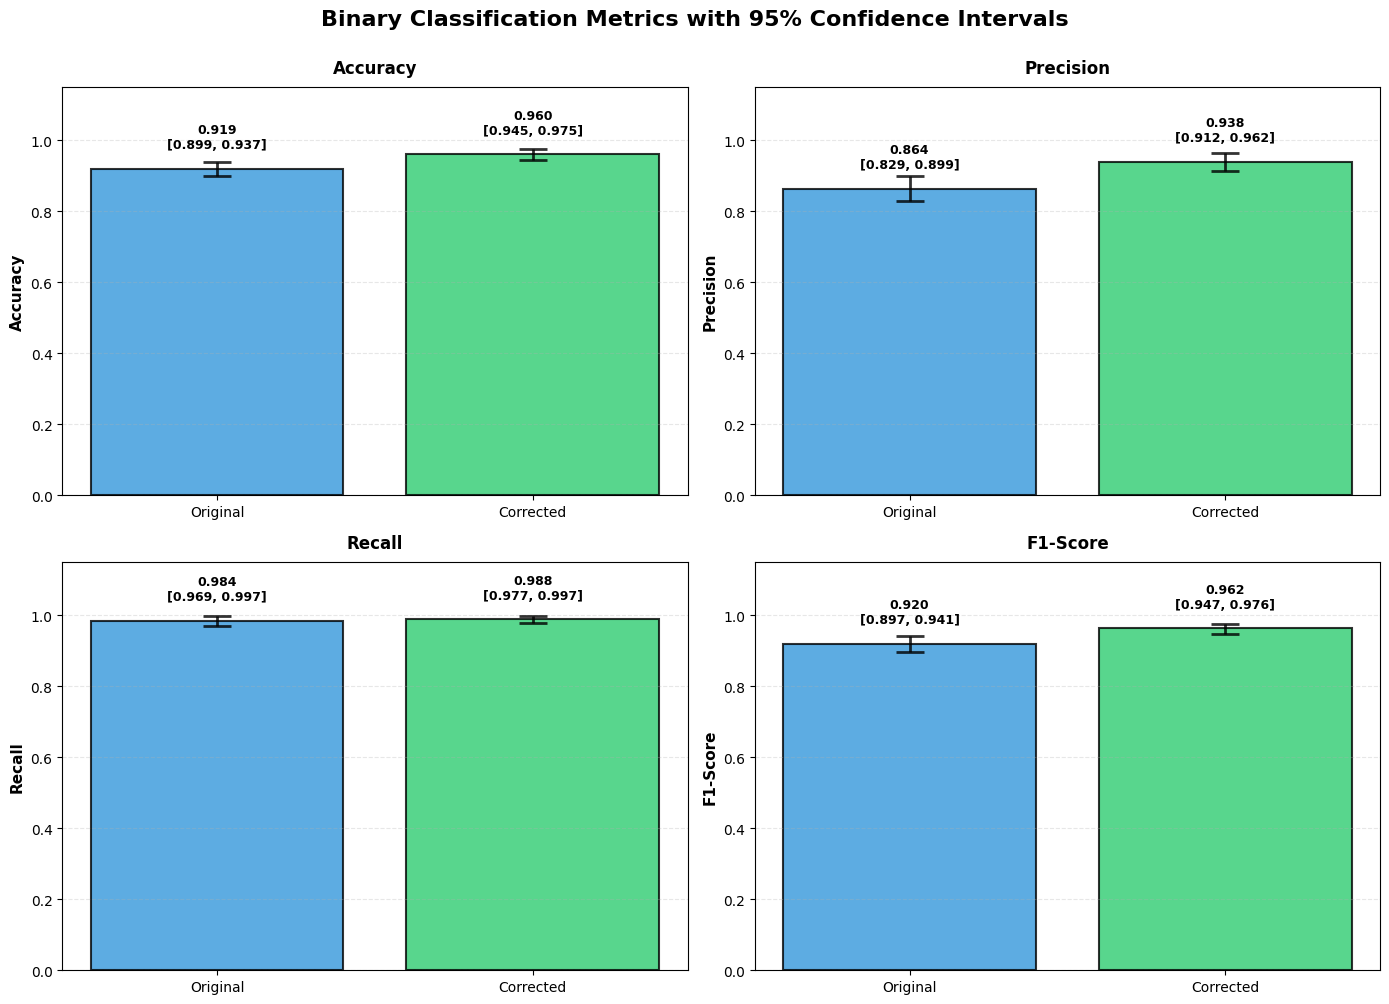

In [30]:
# Visualization 1: Per-Class Precision with 95% CI
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Binary Classification Metrics with 95% Confidence Intervals', 
             fontsize=16, fontweight='bold', y=1.00)

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (ax, metric_name) in enumerate(zip(axes.flat, metrics_list)):
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    datasets = ['Original', 'Corrected']
    means = [orig_mean, corr_mean]
    lowers = [orig_lower, corr_lower]
    uppers = [orig_upper, corr_upper]
    
    # Calculate error bars
    yerr_lower = [means[i] - lowers[i] for i in range(2)]
    yerr_upper = [uppers[i] - means[i] for i in range(2)]
    
    x_pos = np.arange(len(datasets))
    bars = ax.bar(x_pos, means, 
                  color=[color_original, color_corrected],
                  edgecolor='black', linewidth=1.5, alpha=0.8)
    
    # Add error bars
    ax.errorbar(x_pos, means, 
                yerr=[yerr_lower, yerr_upper],
                fmt='none', ecolor='black', capsize=10, 
                capthick=2, linewidth=2, alpha=0.8)
    
    # Add value labels
    for i, (bar, mean, lower, upper) in enumerate(zip(bars, means, lowers, uppers)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                f'{mean:.3f}\n[{lower:.3f}, {upper:.3f}]',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(datasets, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/binary_metrics_with_95_ci.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Export Statistical Results to CSV
ci_results_binary = []

for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    ci_results_binary.append({
        'Metric': metric_name,
        'Original_Mean': orig_mean,
        'Original_CI_Lower': orig_lower,
        'Original_CI_Upper': orig_upper,
        'Original_CI_Width': orig_upper - orig_lower,
        'Corrected_Mean': corr_mean,
        'Corrected_CI_Lower': corr_lower,
        'Corrected_CI_Upper': corr_upper,
        'Corrected_CI_Width': corr_upper - corr_lower,
        'Improvement': corr_mean - orig_mean
    })

df_ci_binary = pd.DataFrame(ci_results_binary)
df_ci_binary.to_csv('random_forest_results/binary_metrics_95ci_random_forest.csv', 
                     index=False)

# Statistical significance results
df_significance = pd.DataFrame(significance_results_corrected)
df_significance.to_csv('random_forest_results/statistical_significance_tests.csv', 
                        index=False)

In [32]:
# Summary Table: All Metrics with CI
print("="*100)
print("COMPREHENSIVE SUMMARY: BINARY CLASSIFICATION WITH 95% CONFIDENCE INTERVALS")
print("="*100)

summary_df = pd.DataFrame({
    'Metric': [],
    'Original': [],
    'Original_95%_CI': [],
    'Corrected': [],
    'Corrected_95%_CI': [],
    'Improvement': [],
    'P-Value': [],
    'Significant': []
})

for i, metric_name in enumerate(['Accuracy', 'Precision', 'Recall', 'F1-Score']):
    orig_mean, orig_lower, orig_upper = metrics_with_ci_orig[metric_name]
    corr_mean, corr_lower, corr_upper = metrics_with_ci_corr[metric_name]
    
    summary_df = pd.concat([summary_df, pd.DataFrame({
        'Metric': [metric_name],
        'Original': [f'{orig_mean:.4f}'],
        'Original_95%_CI': [f'[{orig_lower:.4f}, {orig_upper:.4f}]'],
        'Corrected': [f'{corr_mean:.4f}'],
        'Corrected_95%_CI': [f'[{corr_lower:.4f}, {corr_upper:.4f}]'],
        'Improvement': [f'{corr_mean - orig_mean:+.4f}'],
        'P-Value': [f'{significance_results_corrected[i]["P-Value"]:.4f}'],
        'Significant': [significance_results_corrected[i]['Significant']]
    })], ignore_index=True)

print(summary_df.to_string(index=False))

COMPREHENSIVE SUMMARY: BINARY CLASSIFICATION WITH 95% CONFIDENCE INTERVALS
   Metric Original  Original_95%_CI Corrected Corrected_95%_CI Improvement P-Value Significant
 Accuracy   0.9188 [0.8986, 0.9374]    0.9599 [0.9449, 0.9747]     +0.0412  0.0040         Yes
Precision   0.8637 [0.8293, 0.8992]    0.9382 [0.9121, 0.9625]     +0.0745  0.0000         Yes
   Recall   0.9841 [0.9693, 0.9967]    0.9884 [0.9766, 0.9973]     +0.0043  0.6200          No
 F1-Score   0.9196 [0.8972, 0.9408]    0.9625 [0.9474, 0.9760]     +0.0429  0.0000         Yes


In [33]:
# Calculate Per-Class Metrics with 95% CI for Visualization
class_names = results_orig_multi['class_names']
n_classes = len(class_names)

# Storage for per-class metrics with CI
per_class_metrics_orig = {
    'precision': {'mean': [], 'lower': [], 'upper': []},
    'recall': {'mean': [], 'lower': [], 'upper': []}
}

per_class_metrics_corr = {
    'precision': {'mean': [], 'lower': [], 'upper': []},
    'recall': {'mean': [], 'lower': [], 'upper': []}
}

for class_idx in range(n_classes):
    # Original dataset
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    # Corrected dataset
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # Precision - Original
    prec_orig_mean, prec_orig_lower, prec_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_orig['precision']['mean'].append(prec_orig_mean)
    per_class_metrics_orig['precision']['lower'].append(prec_orig_lower)
    per_class_metrics_orig['precision']['upper'].append(prec_orig_upper)
    
    # Precision - Corrected
    prec_corr_mean, prec_corr_lower, prec_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_corr['precision']['mean'].append(prec_corr_mean)
    per_class_metrics_corr['precision']['lower'].append(prec_corr_lower)
    per_class_metrics_corr['precision']['upper'].append(prec_corr_upper)
    
    # Recall - Original
    rec_orig_mean, rec_orig_lower, rec_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_orig['recall']['mean'].append(rec_orig_mean)
    per_class_metrics_orig['recall']['lower'].append(rec_orig_lower)
    per_class_metrics_orig['recall']['upper'].append(rec_orig_upper)
    
    # Recall - Corrected
    rec_corr_mean, rec_corr_lower, rec_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_metrics_corr['recall']['mean'].append(rec_corr_mean)
    per_class_metrics_corr['recall']['lower'].append(rec_corr_lower)
    per_class_metrics_corr['recall']['upper'].append(rec_corr_upper)

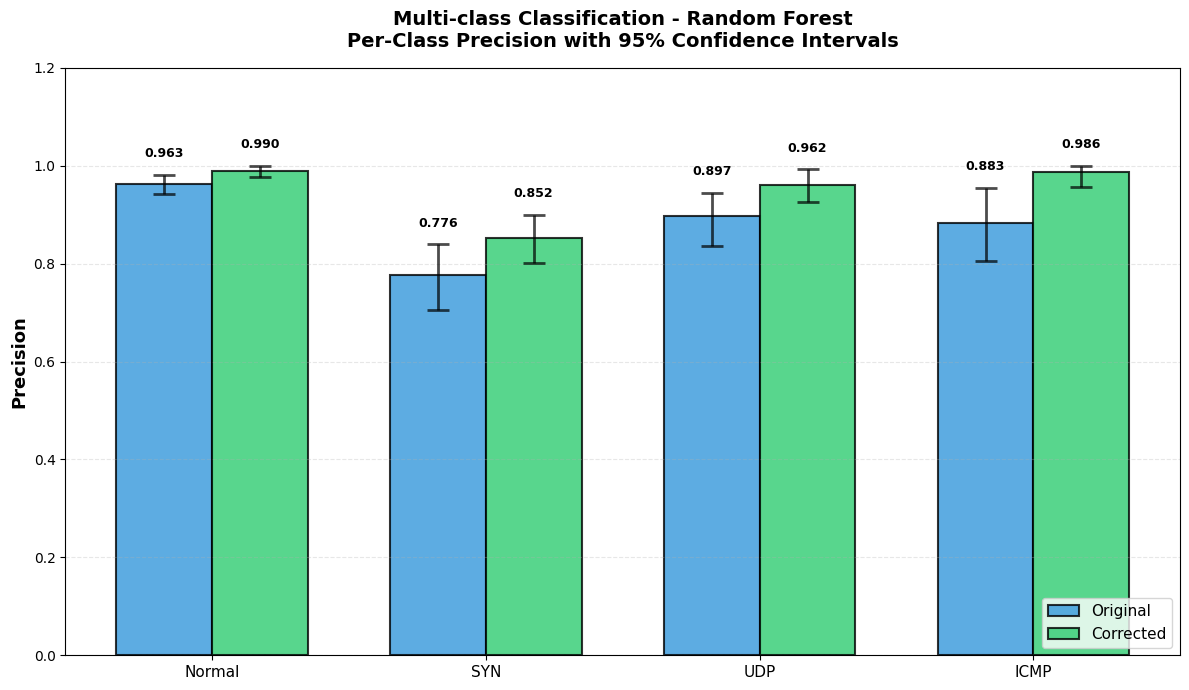

In [34]:
# Visualization 1: Per-Class Precision with 95% CI
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_metrics_orig['precision']['mean']
orig_lowers = per_class_metrics_orig['precision']['lower']
orig_uppers = per_class_metrics_orig['precision']['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_metrics_corr['precision']['mean']
corr_lowers = per_class_metrics_corr['precision']['lower']
corr_uppers = per_class_metrics_corr['precision']['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.03,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.03,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Random Forest\nPer-Class Precision with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_precision_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

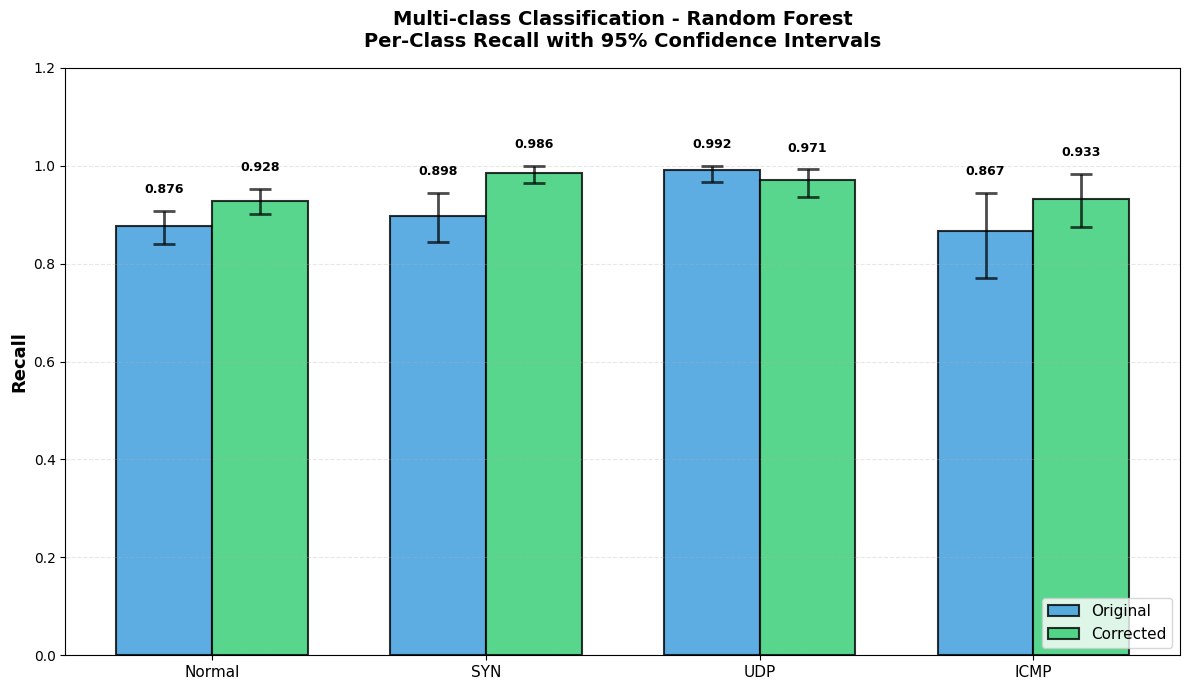

In [35]:
# Visualization 2: Per-Class Recall with 95% CI
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_metrics_orig['recall']['mean']
orig_lowers = per_class_metrics_orig['recall']['lower']
orig_uppers = per_class_metrics_orig['recall']['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_metrics_corr['recall']['mean']
corr_lowers = per_class_metrics_corr['recall']['lower']
corr_uppers = per_class_metrics_corr['recall']['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.03,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.03,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Recall', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Random Forest\nPer-Class Recall with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_recall_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

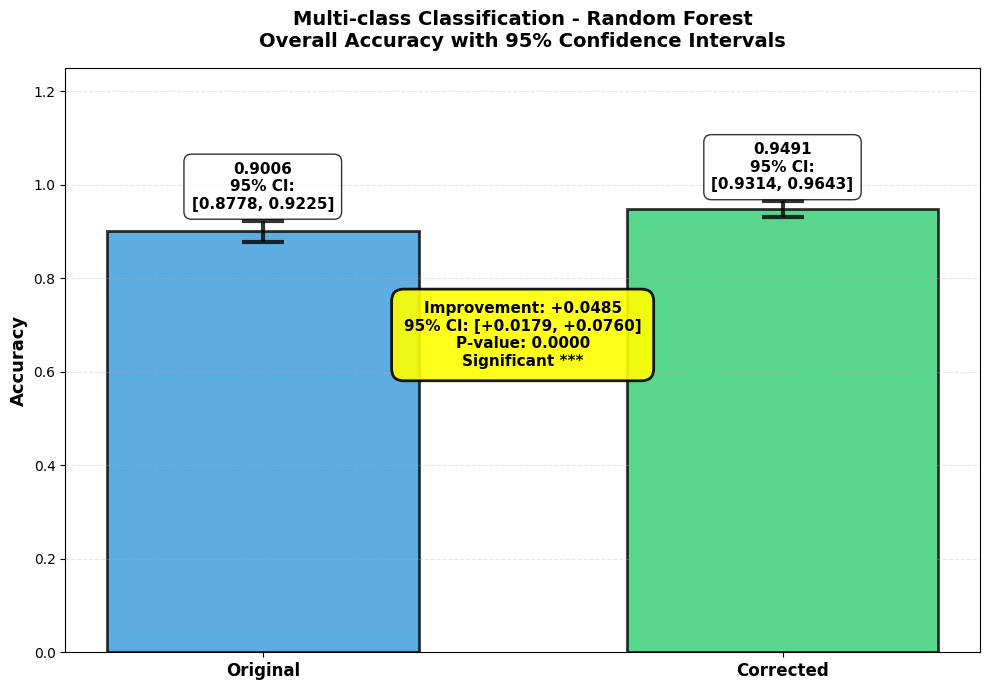


Original Accuracy:  0.9006 [95% CI: 0.8778, 0.9225]
Corrected Accuracy: 0.9491 [95% CI: 0.9314, 0.9643]
Improvement: +0.0485 [95% CI: +0.0179, +0.0760]
P-value: 0.0000 ***


In [36]:
# Visualization 3: Overall Accuracy with 95% CI (Multi-class)

# Calculate confidence intervals for multi-class accuracy
# Original dataset
acc_orig_mean, acc_orig_lower, acc_orig_upper = bootstrap_metric(
    results_orig_multi['y_test'],
    results_orig_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

# Corrected dataset
acc_corr_mean, acc_corr_lower, acc_corr_upper = bootstrap_metric(
    results_corr_multi['y_test'],
    results_corr_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

# Test significance - CORRECTED VERSION
diff_multi, ci_low_multi, ci_high_multi, p_val_multi, sig_multi = bootstrap_difference_test(
    results_orig_multi['y_test'],
    results_orig_multi['y_pred'],
    results_corr_multi['y_test'],
    results_corr_multi['y_pred'],
    accuracy_score,
    n_iterations=1000
)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 7))

datasets = ['Original', 'Corrected']
means = [acc_orig_mean, acc_corr_mean]
lowers = [acc_orig_lower, acc_corr_lower]
uppers = [acc_orig_upper, acc_corr_upper]

yerr_lower = [means[i] - lowers[i] for i in range(2)]
yerr_upper = [uppers[i] - means[i] for i in range(2)]

x_pos = np.arange(len(datasets))

bars = ax.bar(x_pos, means,
              color=[color_original, color_corrected],
              edgecolor='black', linewidth=2, alpha=0.8, width=0.6)

ax.errorbar(x_pos, means,
            yerr=[yerr_lower, yerr_upper],
            fmt='none', ecolor='black', capsize=15,
            capthick=3, linewidth=3, alpha=0.8)

# Add value labels with CI
for i, (bar, mean, lower, upper) in enumerate(zip(bars, means, lowers, uppers)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + yerr_upper[i] + 0.02,
            f'{mean:.4f}\n95% CI:\n[{lower:.4f}, {upper:.4f}]',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
                     edgecolor='black', alpha=0.8))

# Add improvement annotation
improvement_text = (f'Improvement: {diff_multi:+.4f}\n'
                   f'95% CI: [{ci_low_multi:+.4f}, {ci_high_multi:+.4f}]\n'
                   f'P-value: {p_val_multi:.4f}\n'
                   f'{"Significant ***" if sig_multi else "Not Significant"}')

ax.text(0.5, min(means) - 0.15, improvement_text,
        ha='center', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', 
                 facecolor='yellow' if sig_multi else 'lightgray',
                 edgecolor='black', linewidth=2, alpha=0.9))

ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Random Forest\nOverall Accuracy with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.25)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_accuracy_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOriginal Accuracy:  {acc_orig_mean:.4f} [95% CI: {acc_orig_lower:.4f}, {acc_orig_upper:.4f}]")
print(f"Corrected Accuracy: {acc_corr_mean:.4f} [95% CI: {acc_corr_lower:.4f}, {acc_corr_upper:.4f}]")
print(f"Improvement: {diff_multi:+.4f} [95% CI: {ci_low_multi:+.4f}, {ci_high_multi:+.4f}]")
print(f"P-value: {p_val_multi:.4f} {'***' if sig_multi else 'n.s.'}")

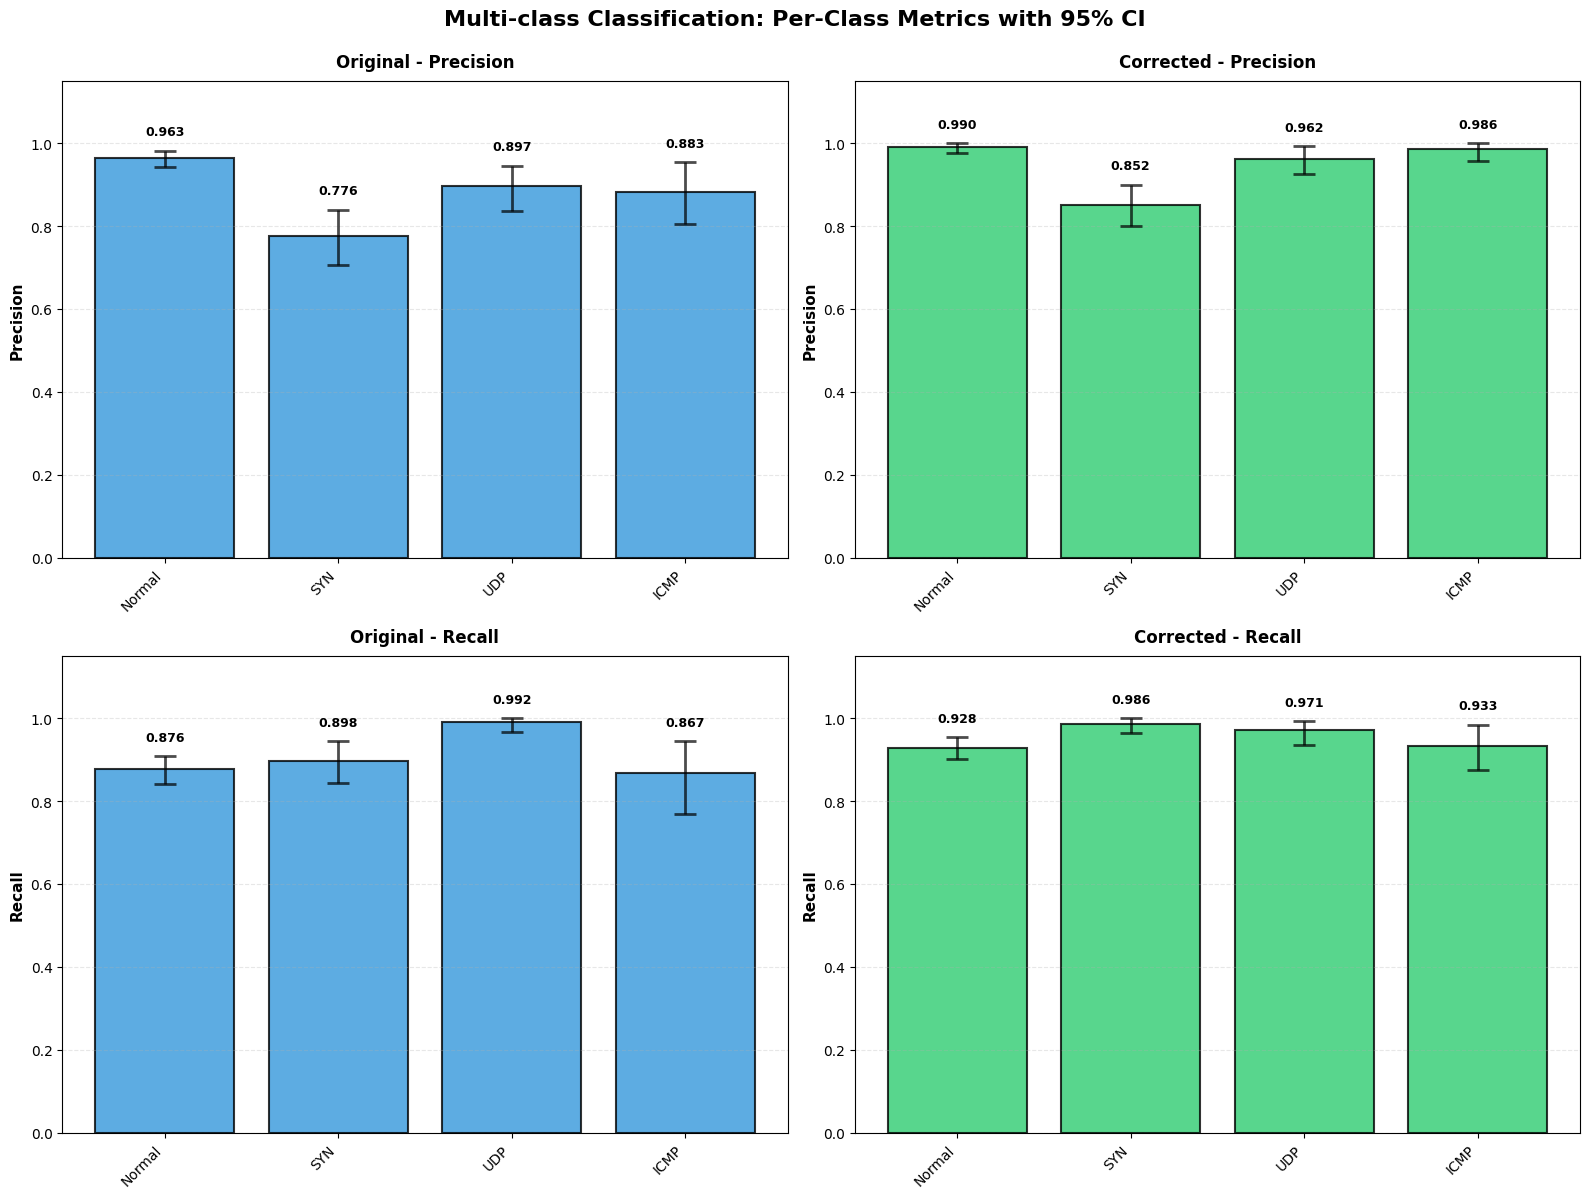

In [37]:
# Visualization 4: Combined Per-Class Metrics (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-class Classification: Per-Class Metrics with 95% CI',
             fontsize=16, fontweight='bold', y=0.995)

metrics_to_plot = ['precision', 'recall']
datasets_labels = ['Original', 'Corrected']

for row_idx, metric_name in enumerate(metrics_to_plot):
    for col_idx, dataset_label in enumerate(datasets_labels):
        ax = axes[row_idx, col_idx]
        
        # Select data
        if dataset_label == 'Original':
            means = per_class_metrics_orig[metric_name]['mean']
            lowers = per_class_metrics_orig[metric_name]['lower']
            uppers = per_class_metrics_orig[metric_name]['upper']
            color = color_original
        else:
            means = per_class_metrics_corr[metric_name]['mean']
            lowers = per_class_metrics_corr[metric_name]['lower']
            uppers = per_class_metrics_corr[metric_name]['upper']
            color = color_corrected
        
        yerr_lower = [means[i] - lowers[i] for i in range(n_classes)]
        yerr_upper = [uppers[i] - means[i] for i in range(n_classes)]
        
        x_pos = np.arange(n_classes)
        
        bars = ax.bar(x_pos, means, color=color,
                     edgecolor='black', linewidth=1.5, alpha=0.8)
        
        ax.errorbar(x_pos, means,
                   yerr=[yerr_lower, yerr_upper],
                   fmt='none', ecolor='black', capsize=8,
                   capthick=2, linewidth=2, alpha=0.7)
        
        # Add value labels
        for i in range(n_classes):
            ax.text(x_pos[i], means[i] + yerr_upper[i] + 0.03,
                   f'{means[i]:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_ylabel(metric_name.capitalize(), fontsize=11, fontweight='bold')
        ax.set_title(f'{dataset_label} - {metric_name.capitalize()}',
                    fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(class_names, fontsize=10, rotation=45, ha='right')
        ax.set_ylim(0, 1.15)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_all_metrics_grid_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

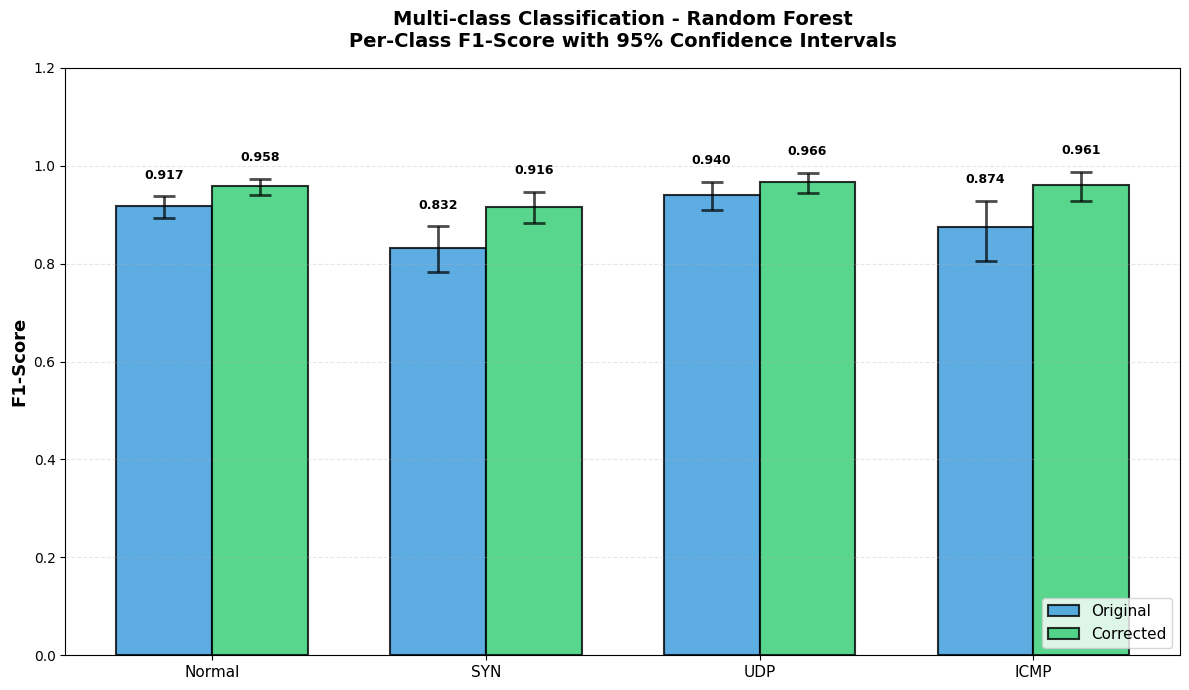

In [38]:
# Visualization 5: Per-Class F1-Score with 95% CI
per_class_f1_orig = {'mean': [], 'lower': [], 'upper': []}
per_class_f1_corr = {'mean': [], 'lower': [], 'upper': []}

for class_idx in range(n_classes):
    # Original dataset
    y_test_orig_binary = (results_orig_multi['y_test'] == class_idx).astype(int)
    y_pred_orig_binary = (results_orig_multi['y_pred'] == class_idx).astype(int)
    
    # Corrected dataset
    y_test_corr_binary = (results_corr_multi['y_test'] == class_idx).astype(int)
    y_pred_corr_binary = (results_corr_multi['y_pred'] == class_idx).astype(int)
    
    # F1 - Original
    f1_orig_mean, f1_orig_lower, f1_orig_upper = bootstrap_metric(
        y_test_orig_binary, y_pred_orig_binary,
        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_f1_orig['mean'].append(f1_orig_mean)
    per_class_f1_orig['lower'].append(f1_orig_lower)
    per_class_f1_orig['upper'].append(f1_orig_upper)
    
    # F1 - Corrected
    f1_corr_mean, f1_corr_lower, f1_corr_upper = bootstrap_metric(
        y_test_corr_binary, y_pred_corr_binary,
        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        n_iterations=500
    )
    per_class_f1_corr['mean'].append(f1_corr_mean)
    per_class_f1_corr['lower'].append(f1_corr_lower)
    per_class_f1_corr['upper'].append(f1_corr_upper)

# Plot F1-Score
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(class_names))
width = 0.35

# Original dataset
orig_means = per_class_f1_orig['mean']
orig_lowers = per_class_f1_orig['lower']
orig_uppers = per_class_f1_orig['upper']
orig_yerr_lower = [orig_means[i] - orig_lowers[i] for i in range(n_classes)]
orig_yerr_upper = [orig_uppers[i] - orig_means[i] for i in range(n_classes)]

bars1 = ax.bar(x_pos - width/2, orig_means, width,
               label='Original', color=color_original,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos - width/2, orig_means,
            yerr=[orig_yerr_lower, orig_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Corrected dataset
corr_means = per_class_f1_corr['mean']
corr_lowers = per_class_f1_corr['lower']
corr_uppers = per_class_f1_corr['upper']
corr_yerr_lower = [corr_means[i] - corr_lowers[i] for i in range(n_classes)]
corr_yerr_upper = [corr_uppers[i] - corr_means[i] for i in range(n_classes)]

bars2 = ax.bar(x_pos + width/2, corr_means, width,
               label='Corrected', color=color_corrected,
               edgecolor='black', linewidth=1.5, alpha=0.8)

ax.errorbar(x_pos + width/2, corr_means,
            yerr=[corr_yerr_lower, corr_yerr_upper],
            fmt='none', ecolor='black', capsize=8,
            capthick=2, linewidth=2, alpha=0.7)

# Add value labels
for i in range(n_classes):
    # Original
    ax.text(x_pos[i] - width/2, orig_means[i] + orig_yerr_upper[i] + 0.03,
            f'{orig_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Corrected
    ax.text(x_pos[i] + width/2, corr_means[i] + corr_yerr_upper[i] + 0.03,
            f'{corr_means[i]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13, fontweight='bold')
ax.set_title('Multi-class Classification - Random Forest\nPer-Class F1-Score with 95% Confidence Intervals',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_f1score_with_95ci.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Export Multi-class Per-Class Results with CI to CSV
multiclass_perclass_ci = []

for class_idx, class_name in enumerate(class_names):
    multiclass_perclass_ci.append({
        'Class': class_name,
        'Precision_Original_Mean': per_class_metrics_orig['precision']['mean'][class_idx],
        'Precision_Original_CI_Lower': per_class_metrics_orig['precision']['lower'][class_idx],
        'Precision_Original_CI_Upper': per_class_metrics_orig['precision']['upper'][class_idx],
        'Precision_Corrected_Mean': per_class_metrics_corr['precision']['mean'][class_idx],
        'Precision_Corrected_CI_Lower': per_class_metrics_corr['precision']['lower'][class_idx],
        'Precision_Corrected_CI_Upper': per_class_metrics_corr['precision']['upper'][class_idx],
        'Precision_Improvement': (per_class_metrics_corr['precision']['mean'][class_idx] - 
                                 per_class_metrics_orig['precision']['mean'][class_idx]),
        'Recall_Original_Mean': per_class_metrics_orig['recall']['mean'][class_idx],
        'Recall_Original_CI_Lower': per_class_metrics_orig['recall']['lower'][class_idx],
        'Recall_Original_CI_Upper': per_class_metrics_orig['recall']['upper'][class_idx],
        'Recall_Corrected_Mean': per_class_metrics_corr['recall']['mean'][class_idx],
        'Recall_Corrected_CI_Lower': per_class_metrics_corr['recall']['lower'][class_idx],
        'Recall_Corrected_CI_Upper': per_class_metrics_corr['recall']['upper'][class_idx],
        'Recall_Improvement': (per_class_metrics_corr['recall']['mean'][class_idx] - 
                              per_class_metrics_orig['recall']['mean'][class_idx]),
        'F1_Original_Mean': per_class_f1_orig['mean'][class_idx],
        'F1_Original_CI_Lower': per_class_f1_orig['lower'][class_idx],
        'F1_Original_CI_Upper': per_class_f1_orig['upper'][class_idx],
        'F1_Corrected_Mean': per_class_f1_corr['mean'][class_idx],
        'F1_Corrected_CI_Lower': per_class_f1_corr['lower'][class_idx],
        'F1_Corrected_CI_Upper': per_class_f1_corr['upper'][class_idx],
        'F1_Improvement': (per_class_f1_corr['mean'][class_idx] - 
                          per_class_f1_orig['mean'][class_idx])
    })

df_multiclass_perclass_ci = pd.DataFrame(multiclass_perclass_ci)
df_multiclass_perclass_ci.to_csv('random_forest_results/multiclass_perclass_metrics_95ci.csv',
                                  index=False)

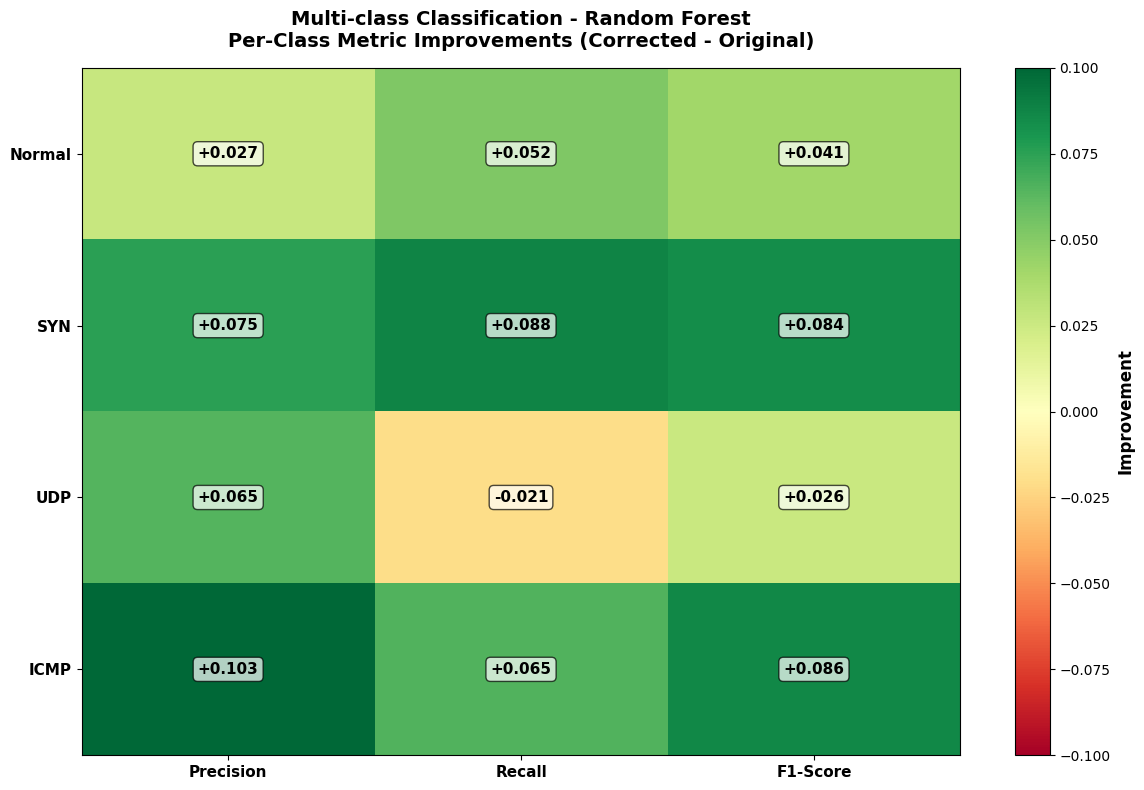

In [40]:
# Summary visualization: Heatmap of improvements with significance
fig, ax = plt.subplots(figsize=(12, 8))

# Create improvement matrix
metrics_names = ['Precision', 'Recall', 'F1-Score']
improvement_matrix = np.zeros((n_classes, len(metrics_names)))

for i in range(n_classes):
    improvement_matrix[i, 0] = (per_class_metrics_corr['precision']['mean'][i] - 
                                per_class_metrics_orig['precision']['mean'][i])
    improvement_matrix[i, 1] = (per_class_metrics_corr['recall']['mean'][i] - 
                                per_class_metrics_orig['recall']['mean'][i])
    improvement_matrix[i, 2] = (per_class_f1_corr['mean'][i] - 
                                per_class_f1_orig['mean'][i])

# Create heatmap
im = ax.imshow(improvement_matrix, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Improvement', fontsize=12, fontweight='bold')

# Set ticks
ax.set_xticks(np.arange(len(metrics_names)))
ax.set_yticks(np.arange(n_classes))
ax.set_xticklabels(metrics_names, fontsize=11, fontweight='bold')
ax.set_yticklabels(class_names, fontsize=11, fontweight='bold')

# Add text annotations
for i in range(n_classes):
    for j in range(len(metrics_names)):
        text = ax.text(j, i, f'{improvement_matrix[i, j]:+.3f}',
                      ha="center", va="center", color="black",
                      fontsize=11, fontweight='bold',
                      bbox=dict(boxstyle='round', facecolor='white', 
                               edgecolor='black', alpha=0.7))

ax.set_title('Multi-class Classification - Random Forest\nPer-Class Metric Improvements (Corrected - Original)',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('random_forest_results/multiclass_improvement_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# Final Summary Table for Multi-class
print("="*120)
print("MULTI-CLASS CLASSIFICATION: COMPREHENSIVE SUMMARY WITH 95% CONFIDENCE INTERVALS")
print("="*120)

summary_multiclass = []

for class_idx, class_name in enumerate(class_names):
    summary_multiclass.append({
        'Class': class_name,
        'Metric': 'Precision',
        'Original': f"{per_class_metrics_orig['precision']['mean'][class_idx]:.3f} "
                   f"[{per_class_metrics_orig['precision']['lower'][class_idx]:.3f}, "
                   f"{per_class_metrics_orig['precision']['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_metrics_corr['precision']['mean'][class_idx]:.3f} "
                    f"[{per_class_metrics_corr['precision']['lower'][class_idx]:.3f}, "
                    f"{per_class_metrics_corr['precision']['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_metrics_corr['precision']['mean'][class_idx] - per_class_metrics_orig['precision']['mean'][class_idx]:+.3f}"
    })
    
    summary_multiclass.append({
        'Class': '',
        'Metric': 'Recall',
        'Original': f"{per_class_metrics_orig['recall']['mean'][class_idx]:.3f} "
                   f"[{per_class_metrics_orig['recall']['lower'][class_idx]:.3f}, "
                   f"{per_class_metrics_orig['recall']['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_metrics_corr['recall']['mean'][class_idx]:.3f} "
                    f"[{per_class_metrics_corr['recall']['lower'][class_idx]:.3f}, "
                    f"{per_class_metrics_corr['recall']['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_metrics_corr['recall']['mean'][class_idx] - per_class_metrics_orig['recall']['mean'][class_idx]:+.3f}"
    })
    
    summary_multiclass.append({
        'Class': '',
        'Metric': 'F1-Score',
        'Original': f"{per_class_f1_orig['mean'][class_idx]:.3f} "
                   f"[{per_class_f1_orig['lower'][class_idx]:.3f}, "
                   f"{per_class_f1_orig['upper'][class_idx]:.3f}]",
        'Corrected': f"{per_class_f1_corr['mean'][class_idx]:.3f} "
                    f"[{per_class_f1_corr['lower'][class_idx]:.3f}, "
                    f"{per_class_f1_corr['upper'][class_idx]:.3f}]",
        'Improvement': f"{per_class_f1_corr['mean'][class_idx] - per_class_f1_orig['mean'][class_idx]:+.3f}"
    })

df_summary_multiclass = pd.DataFrame(summary_multiclass)
print(df_summary_multiclass.to_string(index=False))

# Overall Accuracy
print("\n" + "="*120)
print(f"OVERALL ACCURACY:")
print(f"  Original:  {acc_orig_mean:.4f} [95% CI: {acc_orig_lower:.4f}, {acc_orig_upper:.4f}]")
print(f"  Corrected: {acc_corr_mean:.4f} [95% CI: {acc_corr_lower:.4f}, {acc_corr_upper:.4f}]")
print(f"  Improvement: {diff_multi:+.4f} (p-value: {p_val_multi:.4f}) {'***' if sig_multi else 'n.s.'}")
print("="*120)

MULTI-CLASS CLASSIFICATION: COMPREHENSIVE SUMMARY WITH 95% CONFIDENCE INTERVALS
 Class    Metric             Original            Corrected Improvement
Normal Precision 0.963 [0.941, 0.982] 0.990 [0.977, 1.000]      +0.027
          Recall 0.876 [0.840, 0.908] 0.928 [0.901, 0.953]      +0.052
        F1-Score 0.917 [0.893, 0.938] 0.958 [0.939, 0.973]      +0.041
   SYN Precision 0.776 [0.705, 0.839] 0.852 [0.801, 0.899]      +0.075
          Recall 0.898 [0.844, 0.944] 0.986 [0.964, 1.000]      +0.088
        F1-Score 0.832 [0.783, 0.876] 0.916 [0.884, 0.946]      +0.084
   UDP Precision 0.897 [0.836, 0.945] 0.962 [0.927, 0.993]      +0.065
          Recall 0.992 [0.968, 1.000] 0.971 [0.936, 0.993]      -0.021
        F1-Score 0.940 [0.910, 0.967] 0.966 [0.944, 0.986]      +0.026
  ICMP Precision 0.883 [0.805, 0.954] 0.986 [0.956, 1.000]      +0.103
          Recall 0.867 [0.770, 0.944] 0.933 [0.874, 0.984]      +0.065
        F1-Score 0.874 [0.806, 0.928] 0.961 [0.927, 0.987]      +0.0